In [82]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

In [83]:
train_data = pd.read_csv("data/train.csv")
y_train = train_data[["PassengerId", "Survived"]]
X_test = pd.read_csv("data/test.csv")
y_test = pd.read_csv("data/gender_submission.csv")

In [84]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [85]:
# удаление всех числовых фичей
del_features = ['PassengerId', 'Name', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
train_data = train_data.drop(del_features, axis=1)
train_data.head()

,Survived,Sex,Ticket,Cabin,Embarked
0,0,male,A/5 21171,NaN,S
1,1,female,PC 17599,C85,C
2,1,female,STON/O2. 3101282,NaN,S
3,1,female,113803,C123,S
4,0,male,373450,NaN,S


In [86]:
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Survived  891 non-null    int64
 1   Sex       891 non-null    str  
 2   Ticket    891 non-null    str  
 3   Cabin     204 non-null    str  
 4   Embarked  889 non-null    str  
dtypes: int64(1), str(4)
memory usage: 34.9 KB


In [87]:
train_data.groupby(train_data["Cabin"].isnull())["Survived"].mean()  # True - кабина отуствствует

Cabin
False    0.666667
True     0.299854
Name: Survived, dtype: float64

In [88]:
train_data["haveCabin"] = np.where(train_data["Cabin"].isnull(), 0, 1)
train_data = train_data.drop(["Cabin"], axis=1)
train_data.head()

,Survived,Sex,Ticket,Embarked,haveCabin
0,0,male,A/5 21171,S,0
1,1,female,PC 17599,C,1
2,1,female,STON/O2. 3101282,S,0
3,1,female,113803,S,1
4,0,male,373450,S,0


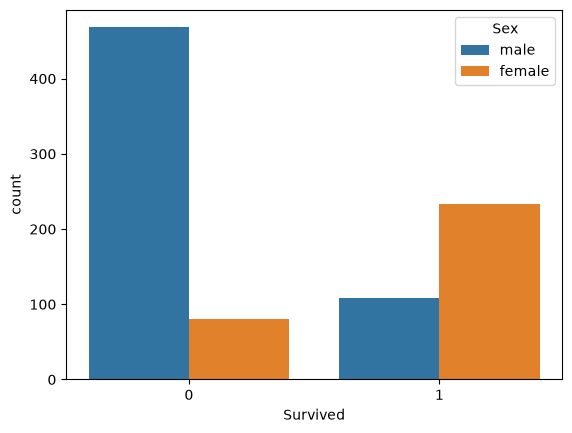

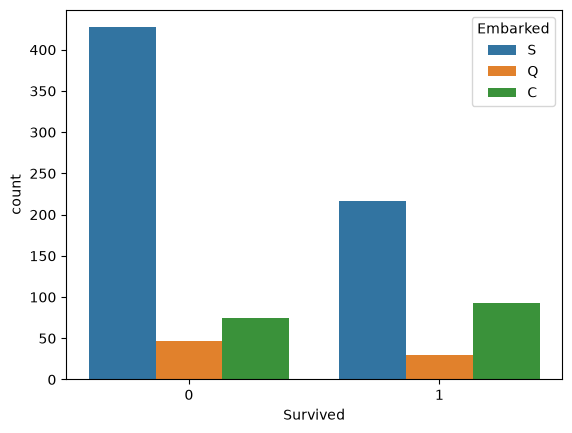

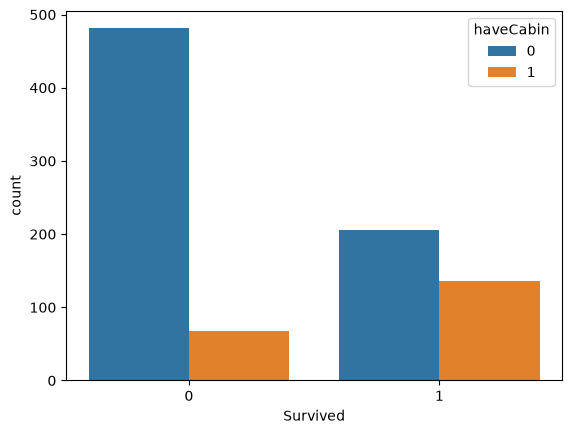

In [95]:
# график зависимости выживаемости от фичей "Sex", "Embarked" и "haveCabin"
for i, feature in enumerate(["Sex", "Embarked", "haveCabin"]):
    plt.figure(i)
    sns.countplot(x='Survived', hue=feature, data=train_data)
    plt.plot()

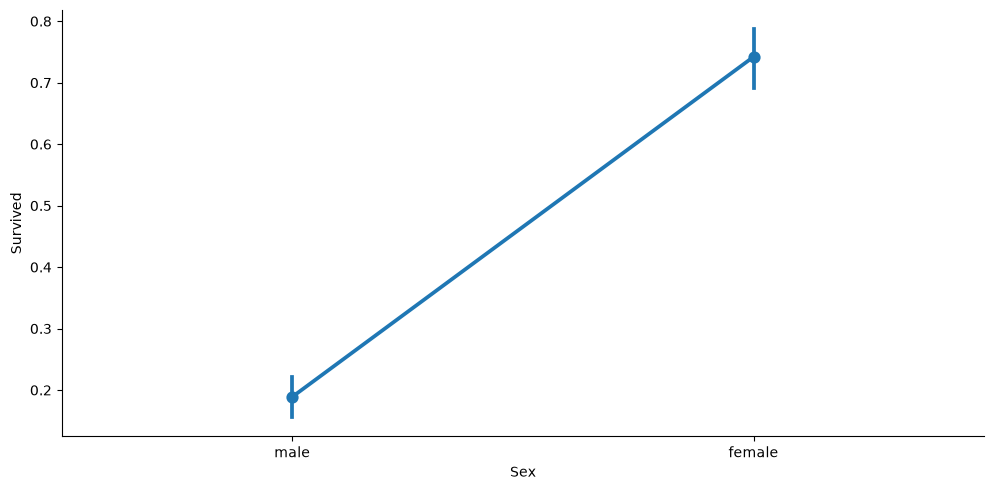

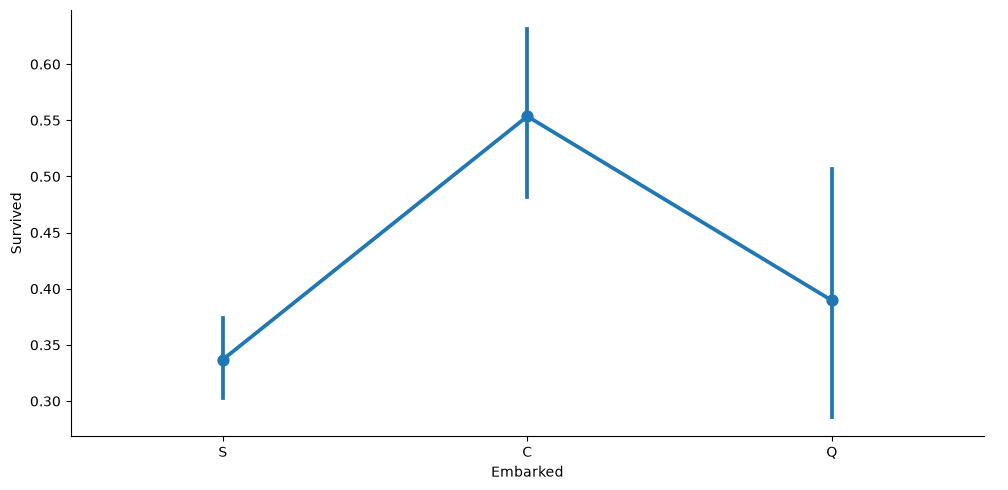

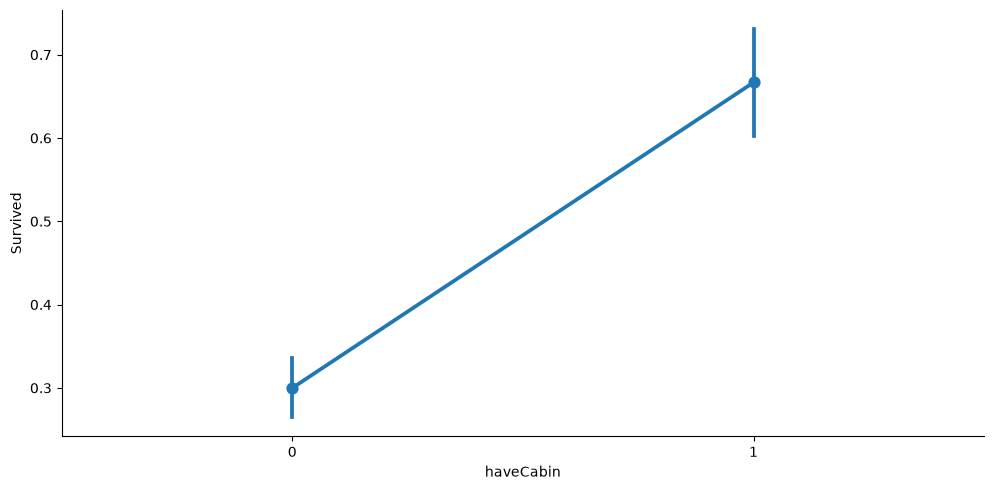

In [92]:
# график зависимости выживаемости от фичей "Sex", "Embarked" и "haveCabin"
for feature in ["Sex", "Embarked", "haveCabin"]:
    sns.catplot(x=feature, y="Survived", data=train_data, kind="point", aspect=2)

In [79]:
train_data = train_data.drop(["Ticket", "Embarked"], axis=1)
train_data.head()

,Survived,Sex,haveCabin
0,0,male,0
1,1,female,1
2,1,female,0
3,1,female,1
4,0,male,0


In [80]:
binary_gender = {"male": 1, "female": 0}
train_data["Sex"] = train_data["Sex"].map(binary_gender)
train_data.head()

,Survived,Sex,haveCabin
0,0,1,0
1,1,0,1
2,1,0,0
3,1,0,1
4,0,1,0


<Axes: >

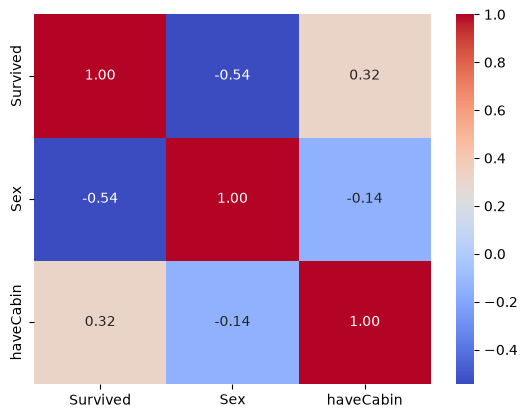

In [81]:
corr_mx = train_data.corr()
corr_mx = train_data.corr(numeric_only=True)
sns.heatmap(corr_mx, annot=True, fmt=".2f", cmap="coolwarm")